# Meeting3

## 가설
> 직원 거주 국가보다 회사 위치가 연봉에 더 큰 영향을 줄 것이다.

## 포함된 분석
1. 기본 EDA
2. 가설을 위한 파생변수 생성
3. **[추가] 거주지-회사위치 중복 비율 확인**
4. 거주 국가와 회사 위치 조합별 EDA
5. 파생변수 기반 모델링
6. 원본 국가 변수 기반 모델링
7. 회귀계수 시각화
8. 국가별 표본 수 확인
9. 파생변수 기반 상관관계 히트맵
10. K-Fold 교차검증
11. 로그 변환 모델링
12. 전체 변수 모델링
13. Ridge / Random Forest 기반 전체 변수 중요도 확인
14. 최종 해석 및 PPT용 요약

## Colab 한글 폰트 설정

그래프 제목은 대부분 영어로 작성했지만, 한글이 필요한 경우를 대비해 Nanum 폰트를 설치합니다.

처음 실행 후 한글이 깨지면 `런타임 > 런타임 다시 시작` 후 처음부터 다시 실행하세요.

In [1]:
# Colab 한글 폰트 설치 및 설정

!apt-get update -qq
!apt-get install -y fonts-nanum > /dev/null

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print("한글 폰트 설정 완료")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
한글 폰트 설정 완료


## 라이브러리 불러오기

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 120)

sns.set_theme(style='whitegrid', font='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

print("Ready")

Ready


## 데이터 불러오기

In [3]:
df_raw = pd.read_csv('ds_salaries.csv')

print("데이터 크기:", df_raw.shape)
display(df_raw.head())

데이터 크기: (607, 12)


,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


## 기본 데이터 구조 확인

In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


In [5]:
display(df_raw.isnull().sum())

,0
Unnamed: 0,0
work_year,0
experience_level,0
employment_type,0
job_title,0
salary,0
salary_currency,0
salary_in_usd,0
employee_residence,0
remote_ratio,0


In [6]:
display(df_raw.describe())

,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,607.000000,6.070000e+02,607.000000,607.00000
mean,303.000000,2021.405272,3.240001e+05,112297.869852,70.92257
std,175.370085,0.692133,1.544357e+06,70957.259411,40.70913
min,0.000000,2020.000000,4.000000e+03,2859.000000,0.00000
25%,151.500000,2021.000000,7.000000e+04,62726.000000,50.00000
50%,303.000000,2022.000000,1.150000e+05,101570.000000,100.00000
75%,454.500000,2022.000000,1.650000e+05,150000.000000,100.00000
max,606.000000,2022.000000,3.040000e+07,600000.000000,100.00000


## 분석용 데이터 정리

`salary`, `salary_currency`는 원본 통화 기준 연봉입니다.  
국가별 통화 단위가 섞여 있으면 직접 비교가 어렵기 때문에, 이번 분석에서는 USD 기준으로 환산된 `salary_in_usd`를 사용합니다.

제거 컬럼:
- `Unnamed: 0`: 단순 인덱스
- `salary`: 원본 통화 기준 금액
- `salary_currency`: 원본 통화 단위

In [7]:
df = df_raw.copy()

drop_cols = ['Unnamed: 0', 'salary', 'salary_currency']
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

print("정리 후 데이터 크기:", df.shape)
display(df.head())

정리 후 데이터 크기: (607, 9)


,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,US,50,US,L


## 컬럼 요약표

In [8]:
column_summary = pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.astype(str),
    'n_unique': [df[col].nunique() for col in df.columns],
    'missing': [df[col].isnull().sum() for col in df.columns]
})

display(column_summary)

,column,dtype,n_unique,missing
work_year,work_year,int64,3,0
experience_level,experience_level,object,4,0
employment_type,employment_type,object,4,0
job_title,job_title,object,50,0
salary_in_usd,salary_in_usd,int64,369,0
employee_residence,employee_residence,object,57,0
remote_ratio,remote_ratio,int64,3,0
company_location,company_location,object,50,0
company_size,company_size,object,3,0


## Target 변수 `salary_in_usd` 분포 확인

연봉 데이터는 일부 고연봉자 때문에 평균이 왜곡될 수 있으므로, 평균과 중앙값, 박스플롯을 함께 확인합니다.

In [9]:
display(df['salary_in_usd'].describe())

print("평균:", df['salary_in_usd'].mean())
print("중앙값:", df['salary_in_usd'].median())
print("최솟값:", df['salary_in_usd'].min())
print("최댓값:", df['salary_in_usd'].max())
print("상위 25% 기준:", df['salary_in_usd'].quantile(0.75))
print("상위 10% 기준:", df['salary_in_usd'].quantile(0.90))

,salary_in_usd
count,607.000000
mean,112297.869852
std,70957.259411
min,2859.000000
25%,62726.000000
50%,101570.000000
75%,150000.000000
max,600000.000000


평균: 112297.86985172982
중앙값: 101570.0
최솟값: 2859
최댓값: 600000
상위 25% 기준: 150000.0
상위 10% 기준: 200000.0


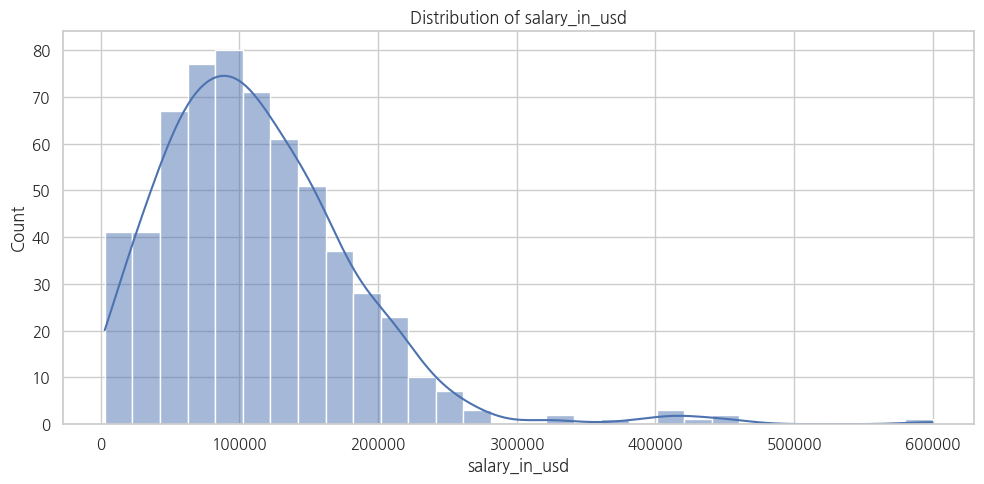

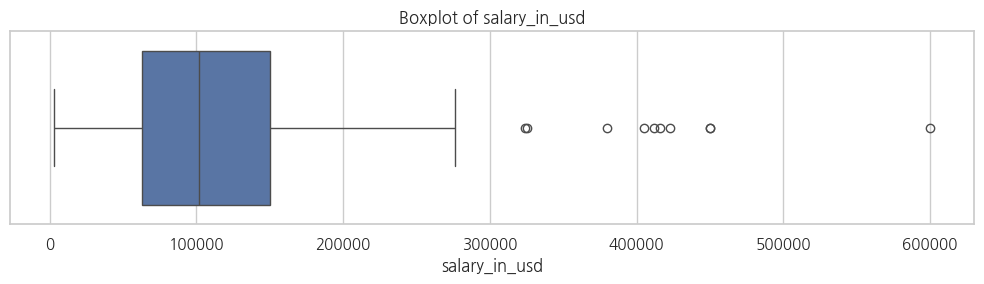

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(df['salary_in_usd'], bins=30, kde=True)
plt.title('Distribution of salary_in_usd')
plt.xlabel('salary_in_usd')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 3))
sns.boxplot(x=df['salary_in_usd'])
plt.title('Boxplot of salary_in_usd')
plt.xlabel('salary_in_usd')
plt.tight_layout()
plt.show()

### 해석

`salary_in_usd`는 평균($112,298)이 중앙값($101,570)보다 높고, 최댓값이 $600,000으로 매우 큽니다.  
따라서 일부 고연봉 데이터가 평균을 끌어올릴 가능성이 있습니다.  
이후 분석에서는 평균뿐 아니라 중앙값과 표본 수를 함께 확인합니다.

## 가설 설정 이유

### 가설
> 직원 거주 국가보다 회사 위치가 연봉에 더 큰 영향을 줄 것이다.

데이터 직군은 원격근무와 글로벌 채용 가능성이 높은 직군입니다.  
따라서 직원이 실제로 거주하는 국가와 회사가 위치한 국가가 다를 수 있습니다.

이때 연봉이 직원의 거주 국가 기준으로 결정되는지,  
아니면 회사 위치의 임금 기준에 더 가까운지 확인하고자 했습니다.

## 파생변수 생성

원본 변수인 `employee_residence`, `company_location`은 국가 코드가 많아 직접 비교하면 해석이 복잡합니다.  
기본 EDA에서 미국 거주자와 미국 회사의 비중이 높게 나타났기 때문에, 먼저 미국 여부를 기준으로 단순화합니다.

| 파생변수 | 의미 |
|---|---|
| `is_us_residence` | 직원이 미국에 거주하는지 여부 |
| `is_us_company` | 회사 위치가 미국인지 여부 |

주의: 이 파생변수는 해석을 쉽게 만들지만, 미국 외 국가들의 차이를 모두 하나로 묶는 한계가 있습니다.

In [11]:
df['is_us_residence'] = np.where(
    df['employee_residence'] == 'US',
    'US residence',
    'Non-US residence'
)

df['is_us_company'] = np.where(
    df['company_location'] == 'US',
    'US company',
    'Non-US company'
)

display(df[['employee_residence', 'company_location', 'is_us_residence', 'is_us_company']].head())

print("is_us_residence")
display(df['is_us_residence'].value_counts())

print("is_us_company")
display(df['is_us_company'].value_counts())

,employee_residence,company_location,is_us_residence,is_us_company
0,DE,DE,Non-US residence,Non-US company
1,JP,JP,Non-US residence,Non-US company
2,GB,GB,Non-US residence,Non-US company
3,HN,HN,Non-US residence,Non-US company
4,US,US,US residence,US company


is_us_residence


,count
is_us_residence,
US residence,332
Non-US residence,275


is_us_company


,count
is_us_company,
US company,355
Non-US company,252


## 거주지와 회사위치 중복 비율 확인

가설 B의 전제는 직원 거주 국가와 회사 위치가 **독립적으로** 연봉에 영향을 준다는 것입니다.  
하지만 만약 두 변수가 대부분 동일한 값을 가진다면, 독립적인 비교 자체에 한계가 생깁니다.

따라서 본격적인 비교 전에 두 변수가 얼마나 겹치는지 먼저 확인합니다.

In [12]:
# 거주지와 회사위치가 같은 행 비율
same_country = (df['employee_residence'] == df['company_location']).mean()
same_count = (df['employee_residence'] == df['company_location']).sum()
total_count = len(df)

print(f"전체 데이터 수: {total_count}")
print(f"거주지 == 회사위치인 데이터 수: {same_count}")
print(f"거주지 == 회사위치 비율: {same_country:.1%}")
print()
print("→ 두 변수가 91.6% 동일하므로, 독립적인 비교에 구조적 한계가 존재합니다.")
print("  거주지 ≠ 회사위치인 원격/해외 근무자는 전체의 약 8.4%(51명)에 불과합니다.")
print("  이 사실은 이후 EDA와 모델 해석에서 반드시 함께 고려해야 합니다.")

전체 데이터 수: 607
거주지 == 회사위치인 데이터 수: 556
거주지 == 회사위치 비율: 91.6%

→ 두 변수가 91.6% 동일하므로, 독립적인 비교에 구조적 한계가 존재합니다.
  거주지 ≠ 회사위치인 원격/해외 근무자는 전체의 약 8.4%(51명)에 불과합니다.
  이 사실은 이후 EDA와 모델 해석에서 반드시 함께 고려해야 합니다.


### 해석

두 변수가 91.6% 동일하다는 것은,  
대부분의 데이터에서 직원 거주 국가와 회사 위치가 같다는 뜻입니다.

이는 이후 모델 비교 결과에도 영향을 줍니다:  
두 변수의 정보가 대부분 겹치기 때문에 `employee_residence`와 `company_location`을 분리해서 비교하는 것에 한계가 있습니다.  
결과 해석 시 이 구조적 제약을 명시하는 것이 중요합니다.

## EDA 1: 미국 거주 여부와 미국 회사 여부별 연봉 비교

In [13]:
us_residence_salary = df.groupby('is_us_residence')['salary_in_usd'].agg(
    count='count',
    mean='mean',
    median='median',
    min='min',
    max='max'
)

us_company_salary = df.groupby('is_us_company')['salary_in_usd'].agg(
    count='count',
    mean='mean',
    median='median',
    min='min',
    max='max'
)

display(us_residence_salary)
display(us_company_salary)

,count,mean,median,min,max
is_us_residence,,,,,
Non-US residence,275,67754.036364,62649.0,2859,260000
US residence,332,149194.117470,138475.0,25000,600000


,count,mean,median,min,max
is_us_company,,,,,
Non-US company,252,67560.273810,62688.5,2859,260000
US company,355,144055.261972,135000.0,5679,600000


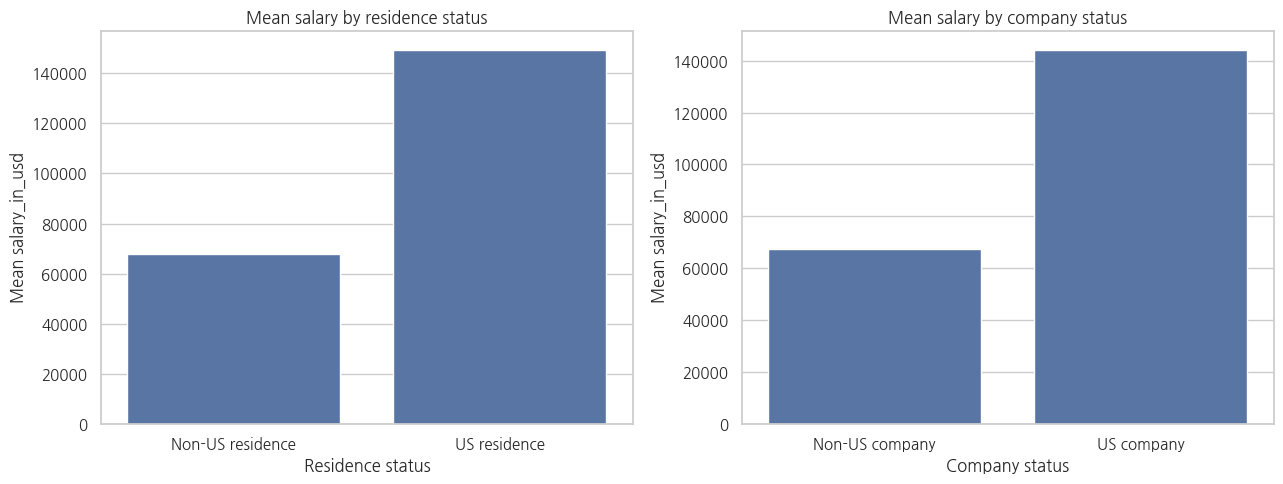

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(
    data=us_residence_salary.reset_index(),
    x='is_us_residence',
    y='mean',
    ax=axes[0]
)
axes[0].set_title('Mean salary by residence status')
axes[0].set_xlabel('Residence status')
axes[0].set_ylabel('Mean salary_in_usd')

sns.barplot(
    data=us_company_salary.reset_index(),
    x='is_us_company',
    y='mean',
    ax=axes[1]
)
axes[1].set_title('Mean salary by company status')
axes[1].set_xlabel('Company status')
axes[1].set_ylabel('Mean salary_in_usd')

plt.tight_layout()
plt.show()

## EDA 2: 거주 국가와 회사 위치 조합 비교

가설 B의 핵심은 직원 거주 국가와 회사 위치를 동시에 보는 것입니다.

In [15]:
residence_company = df.groupby(
    ['is_us_residence', 'is_us_company']
)['salary_in_usd'].agg(
    count='count',
    mean='mean',
    median='median',
    min='min',
    max='max'
).reset_index().sort_values('mean', ascending=False)

display(residence_company)

# 표본 수 경고
small_cells = residence_company[residence_company['count'] < 10]
if len(small_cells) > 0:
    print()
    print("⚠️ 표본 수 경고: 아래 조합은 n<10으로 통계적으로 불안정합니다.")
    for _, row in small_cells.iterrows():
        print(f"   - {row['is_us_residence']} + {row['is_us_company']}: n={int(row['count'])} (평균 ${row['mean']:,.0f}) → 해석에서 제외 권장")

,is_us_residence,is_us_company,count,mean,median,min,max
2,US residence,Non-US company,2,188500.000,188500.0,152000,225000
3,US residence,US company,330,148955.900,138175.0,25000,600000
1,Non-US residence,US company,25,79366.840,60000.0,5679,200000
0,Non-US residence,Non-US company,250,66592.756,62650.0,2859,260000



⚠️ 표본 수 경고: 아래 조합은 n<10으로 통계적으로 불안정합니다.
   - US residence + Non-US company: n=2 (평균 $188,500) → 해석에서 제외 권장


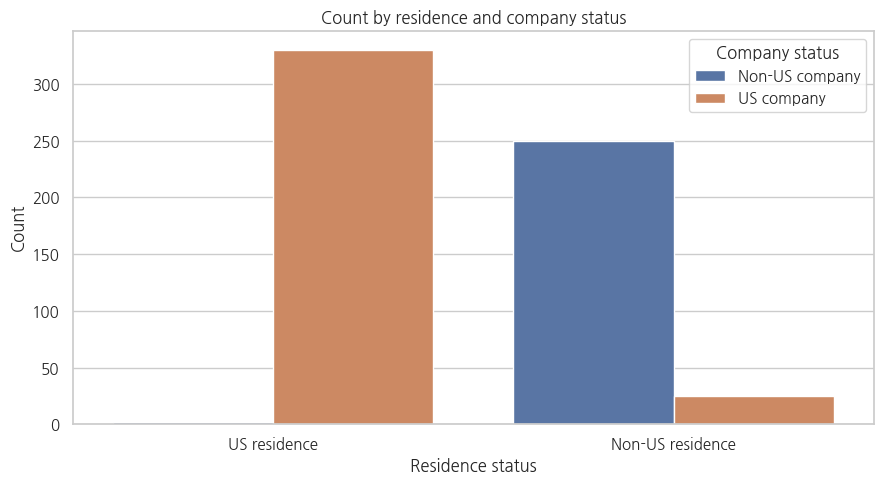

In [16]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=residence_company,
    x='is_us_residence',
    y='count',
    hue='is_us_company'
)

plt.title('Count by residence and company status')
plt.xlabel('Residence status')
plt.ylabel('Count')
plt.legend(title='Company status')
plt.tight_layout()
plt.show()

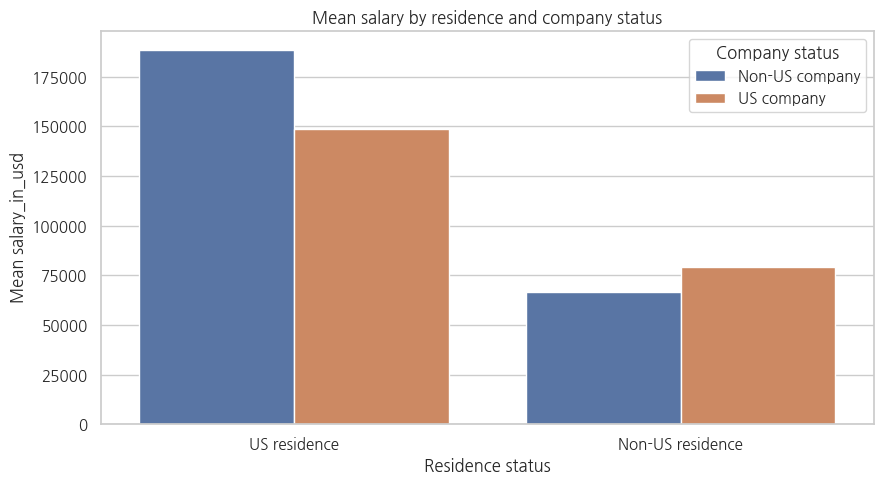

In [17]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=residence_company,
    x='is_us_residence',
    y='mean',
    hue='is_us_company'
)

plt.title('Mean salary by residence and company status')
plt.xlabel('Residence status')
plt.ylabel('Mean salary_in_usd')
plt.legend(title='Company status')
plt.tight_layout()
plt.show()

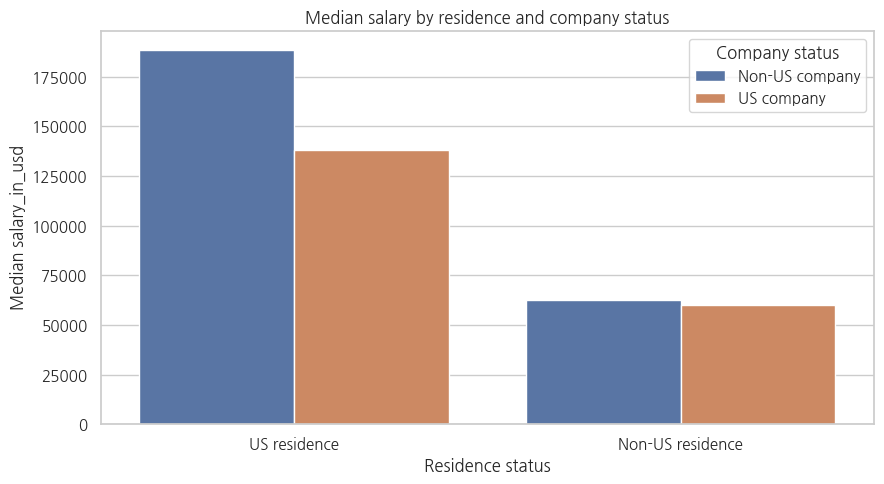

In [18]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=residence_company,
    x='is_us_residence',
    y='median',
    hue='is_us_company'
)

plt.title('Median salary by residence and company status')
plt.xlabel('Residence status')
plt.ylabel('Median salary_in_usd')
plt.legend(title='Company status')
plt.tight_layout()
plt.show()

### EDA 해석

- `US residence + US company` 조합은 표본 수(n=330)가 많고 평균/중앙값 모두 높은 편입니다.
- `Non-US residence + Non-US company` 조합(n=250)이 그 다음으로 표본이 많으나 연봉이 낮습니다.
- **`US residence + Non-US company`는 n=2로 통계적으로 무의미한 셀입니다. 평균 $188,500이 높게 나타나도 해석에서 제외해야 합니다.**
- `Non-US residence + US company`(n=25)도 표본이 적어 해석에 주의가 필요합니다.

따라서 EDA만으로는 회사 위치가 직원 거주 국가보다 더 중요하다고 확정하기 어렵습니다.

## 모델링 평가 지표 설명

| 지표 | 의미 | 해석 |
|---|---|---|
| MAE | 평균 절대 오차 | 실제 연봉과 예측 연봉이 평균적으로 얼마나 차이 나는지 |
| RMSE | 제곱 평균 제곱근 오차 | 큰 오차에 더 민감한 예측 오차 |
| R² | 설명력 | 모델이 연봉 변동을 얼마나 설명하는지 |

MAE와 RMSE는 낮을수록 좋고, R²는 높을수록 좋습니다.

## 파생변수 기반 모델 비교

### 목적
미국 거주 여부와 미국 회사 여부 중 어떤 변수가 연봉 예측에 더 유용한지 확인합니다.

### 비교 모델
| 모델 | 사용 변수 |
|---|---|
| Model D | `is_us_residence` only |
| Model E | `is_us_company` only |
| Model F | `is_us_residence + is_us_company` |

In [19]:
y = df['salary_in_usd']

In [20]:
# Model D: is_us_residence only

X_d = df[['is_us_residence']]
X_d_encoded = pd.get_dummies(X_d, drop_first=True)

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_d_encoded, y, test_size=0.2, random_state=42
)

model_d = LinearRegression()
model_d.fit(X_train_d, y_train_d)

pred_d = model_d.predict(X_test_d)

mae_d = mean_absolute_error(y_test_d, pred_d)
rmse_d = np.sqrt(mean_squared_error(y_test_d, pred_d))
r2_d = r2_score(y_test_d, pred_d)

In [21]:
# Model E: is_us_company only

X_e = df[['is_us_company']]
X_e_encoded = pd.get_dummies(X_e, drop_first=True)

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_e_encoded, y, test_size=0.2, random_state=42
)

model_e = LinearRegression()
model_e.fit(X_train_e, y_train_e)

pred_e = model_e.predict(X_test_e)

mae_e = mean_absolute_error(y_test_e, pred_e)
rmse_e = np.sqrt(mean_squared_error(y_test_e, pred_e))
r2_e = r2_score(y_test_e, pred_e)

In [22]:
# Model F: is_us_residence + is_us_company

X_f = df[['is_us_residence', 'is_us_company']]
X_f_encoded = pd.get_dummies(X_f, drop_first=True)

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_f_encoded, y, test_size=0.2, random_state=42
)

model_f = LinearRegression()
model_f.fit(X_train_f, y_train_f)

pred_f = model_f.predict(X_test_f)

mae_f = mean_absolute_error(y_test_f, pred_f)
rmse_f = np.sqrt(mean_squared_error(y_test_f, pred_f))
r2_f = r2_score(y_test_f, pred_f)

In [23]:
derived_location_model_results = pd.DataFrame({
    'model': [
        'is_us_residence only',
        'is_us_company only',
        'is_us_residence + is_us_company'
    ],
    'MAE': [mae_d, mae_e, mae_f],
    'RMSE': [rmse_d, rmse_e, rmse_f],
    'R2': [r2_d, r2_e, r2_f]
})

display(derived_location_model_results.sort_values('RMSE'))

,model,MAE,RMSE,R2
0,is_us_residence only,35392.911199,47727.555670,0.405642
2,is_us_residence + is_us_company,35402.383802,47729.176647,0.405601
1,is_us_company only,35270.315217,49117.511898,0.370519


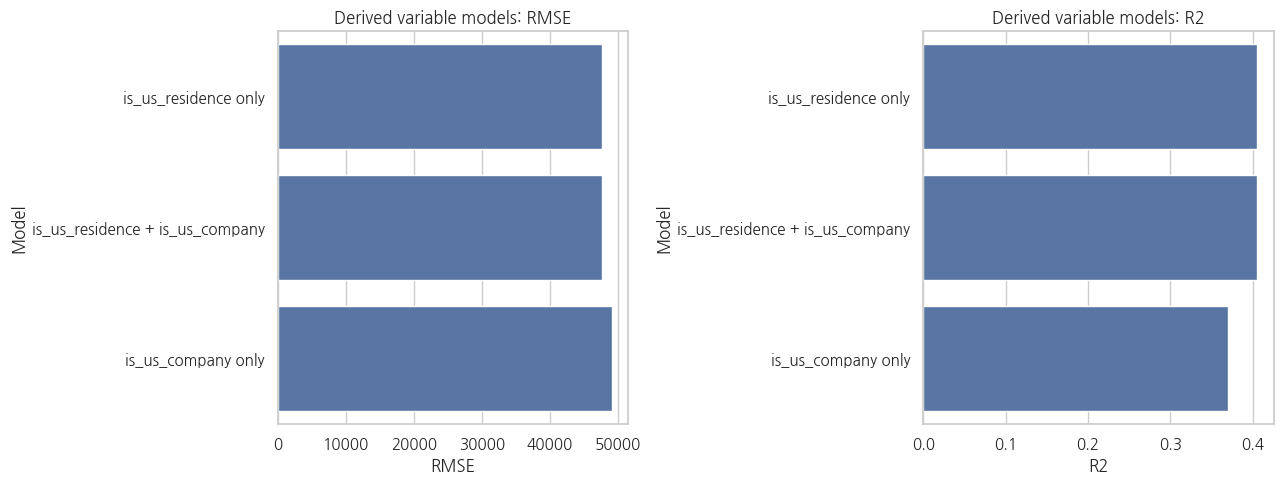

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_data = derived_location_model_results.sort_values('RMSE')

sns.barplot(data=plot_data, y='model', x='RMSE', ax=axes[0])
axes[0].set_title('Derived variable models: RMSE')
axes[0].set_xlabel('RMSE')
axes[0].set_ylabel('Model')

sns.barplot(data=plot_data.sort_values('R2', ascending=False), y='model', x='R2', ax=axes[1])
axes[1].set_title('Derived variable models: R2')
axes[1].set_xlabel('R2')
axes[1].set_ylabel('Model')

plt.tight_layout()
plt.show()

### 파생변수 기반 모델 해석

파생변수 모델은 `US / Non-US`로 단순화했기 때문에 해석은 쉽습니다.  
하지만 국가별 세부 차이를 반영하지 못합니다.

이 모델에서 `is_us_company`가 `is_us_residence`보다 뚜렷하게 좋은 성능을 보이지 않는다면,  
가설 B는 강하게 지지되었다고 보기 어렵습니다.

## 원본 국가 변수 기반 모델 비교

파생변수는 단순하지만, 미국 외 국가들의 차이를 모두 `Non-US`로 묶는 한계가 있습니다.  
따라서 원본 변수인 `employee_residence`, `company_location`을 그대로 사용하여 다시 비교합니다.

### 비교 모델
| 모델 | 사용 변수 |
|---|---|
| Model A | `employee_residence` only |
| Model B | `company_location` only |
| Model C | `employee_residence + company_location` |

In [25]:
# Model A: employee_residence only

X_a = df[['employee_residence']]
X_a_encoded = pd.get_dummies(X_a, drop_first=True)

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_a_encoded, y, test_size=0.2, random_state=42
)

model_a = LinearRegression()
model_a.fit(X_train_a, y_train_a)

pred_a = model_a.predict(X_test_a)

mae_a = mean_absolute_error(y_test_a, pred_a)
rmse_a = np.sqrt(mean_squared_error(y_test_a, pred_a))
r2_a = r2_score(y_test_a, pred_a)

In [26]:
# Model B: company_location only

X_b = df[['company_location']]
X_b_encoded = pd.get_dummies(X_b, drop_first=True)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_b_encoded, y, test_size=0.2, random_state=42
)

model_b = LinearRegression()
model_b.fit(X_train_b, y_train_b)

pred_b = model_b.predict(X_test_b)

mae_b = mean_absolute_error(y_test_b, pred_b)
rmse_b = np.sqrt(mean_squared_error(y_test_b, pred_b))
r2_b = r2_score(y_test_b, pred_b)

In [27]:
# Model C: employee_residence + company_location

X_c = df[['employee_residence', 'company_location']]
X_c_encoded = pd.get_dummies(X_c, drop_first=True)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c_encoded, y, test_size=0.2, random_state=42
)

model_c = LinearRegression()
model_c.fit(X_train_c, y_train_c)

pred_c = model_c.predict(X_test_c)

mae_c = mean_absolute_error(y_test_c, pred_c)
rmse_c = np.sqrt(mean_squared_error(y_test_c, pred_c))
r2_c = r2_score(y_test_c, pred_c)

In [28]:
original_location_model_results = pd.DataFrame({
    'model': [
        'employee_residence only',
        'company_location only',
        'employee_residence + company_location'
    ],
    'MAE': [mae_a, mae_b, mae_c],
    'RMSE': [rmse_a, rmse_b, rmse_c],
    'R2': [r2_a, r2_b, r2_c]
})

display(original_location_model_results.sort_values('RMSE'))

,model,MAE,RMSE,R2
0,employee_residence only,32786.259083,46301.403954,0.440631
1,company_location only,34427.609507,49585.375555,0.358470
2,employee_residence + company_location,34886.596383,50122.928803,0.344485


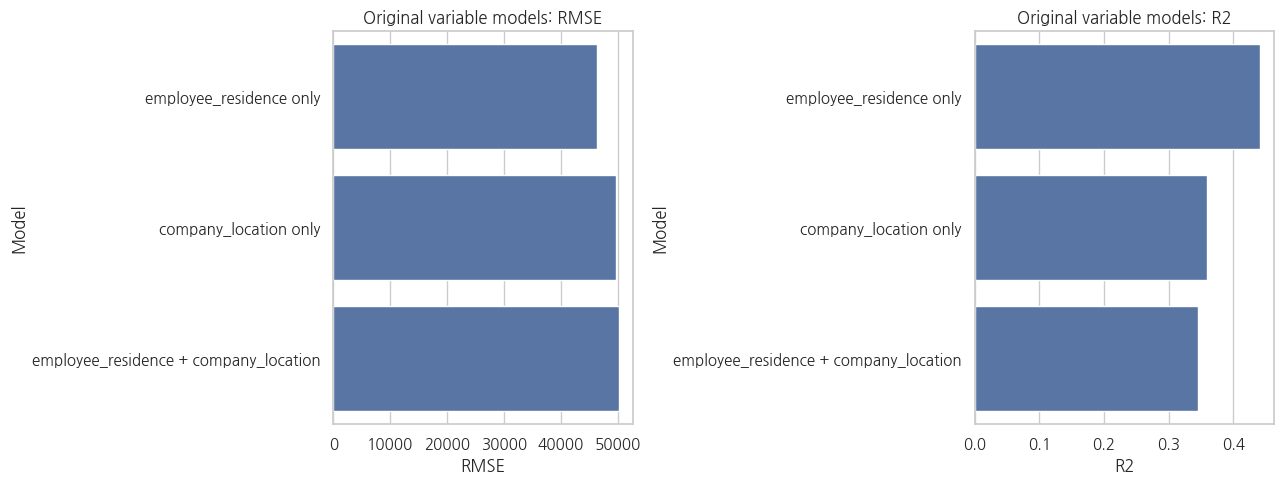

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_data = original_location_model_results.sort_values('RMSE')

sns.barplot(data=plot_data, y='model', x='RMSE', ax=axes[0])
axes[0].set_title('Original variable models: RMSE')
axes[0].set_xlabel('RMSE')
axes[0].set_ylabel('Model')

sns.barplot(data=plot_data.sort_values('R2', ascending=False), y='model', x='R2', ax=axes[1])
axes[1].set_title('Original variable models: R2')
axes[1].set_xlabel('R2')
axes[1].set_ylabel('Model')

plt.tight_layout()
plt.show()

### 원본 변수 기반 모델 해석

원본 국가 변수를 사용하면 `US / Non-US`로 단순화하지 않고 국가별 차이를 더 반영할 수 있습니다.  
`employee_residence only` 모델이 가장 낮은 RMSE(46,301)와 가장 높은 R²(0.44)를 보였습니다.  
초기 가설과 달리 직원 거주 국가가 회사 위치보다 연봉 예측에 더 유용한 변수로 나타났습니다.

두 변수를 함께 사용한 Model C가 오히려 성능이 낮은 것은 두 변수의 정보가 91.6% 겹치기 때문에  
추가적인 정보보다 노이즈가 늘어난 결과로 해석할 수 있습니다.

## 14. Dummy baseline과 비교

모델 성능이 의미 있는지 보려면 단순 평균 예측 모델과 비교하는 것이 좋습니다.  
DummyRegressor는 평균값만 예측하는 기준 모델입니다.

In [30]:
X_dummy = pd.get_dummies(df[['employee_residence']], drop_first=True)

X_train_dummy, X_test_dummy, y_train_dummy, y_test_dummy = train_test_split(
    X_dummy, y, test_size=0.2, random_state=42
)

dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train_dummy, y_train_dummy)

dummy_pred = dummy.predict(X_test_dummy)

dummy_mae = mean_absolute_error(y_test_dummy, dummy_pred)
dummy_rmse = np.sqrt(mean_squared_error(y_test_dummy, dummy_pred))
dummy_r2 = r2_score(y_test_dummy, dummy_pred)

baseline_compare = pd.DataFrame({
    'model': [
        'Dummy baseline (mean prediction)',
        'employee_residence only',
        'company_location only',
        'employee_residence + company_location'
    ],
    'MAE': [dummy_mae, mae_a, mae_b, mae_c],
    'RMSE': [dummy_rmse, rmse_a, rmse_b, rmse_c],
    'R2': [dummy_r2, r2_a, r2_b, r2_c]
})

display(baseline_compare.sort_values('RMSE'))

print()
print("참고: Dummy baseline의 R²가 음수(-0.02)인 것은 정상 범위입니다.")
print("train 평균이 test 분포와 맞지 않을 때 발생하며, 모든 실제 모델은 이보다 높은 R²를 보입니다.")

,model,MAE,RMSE,R2
1,employee_residence only,32786.259083,46301.403954,0.440631
2,company_location only,34427.609507,49585.375555,0.358470
3,employee_residence + company_location,34886.596383,50122.928803,0.344485
0,Dummy baseline (mean prediction),47004.474396,62593.644205,-0.022281



참고: Dummy baseline의 R²가 음수(-0.02)인 것은 정상 범위입니다.
train 평균이 test 분포와 맞지 않을 때 발생하며, 모든 실제 모델은 이보다 높은 R²를 보입니다.


## 15. 회귀계수 시각화

회귀계수는 특정 더미 변수가 기준 범주에 비해 연봉을 얼마나 높이거나 낮추는 방향으로 작용했는지 보여줍니다.

주의:
- `pd.get_dummies(drop_first=True)`를 사용했기 때문에 하나의 국가는 기준값으로 빠집니다.
- 계수가 크다고 인과관계를 의미하지 않습니다.
- 표본 수가 적은 국가는 계수가 불안정할 수 있습니다.

,feature,coefficient
37,employee_residence_MY,1.075000e+05
44,employee_residence_PR,6.750000e+04
54,employee_residence_US,5.787266e+04
40,employee_residence_NZ,3.250000e+04
2,employee_residence_AU,1.554267e+04
31,employee_residence_JP,1.540000e+04
48,employee_residence_RU,1.325000e+04
49,employee_residence_SG,1.167650e+04
27,employee_residence_IQ,7.500000e+03
15,employee_residence_DZ,7.500000e+03


,feature,coefficient
14,employee_residence_DK,-55247.50
24,employee_residence_HU,-56503.00
26,employee_residence_IN,-57488.04
36,employee_residence_MX,-58989.00
16,employee_residence_EE,-59526.00
51,employee_residence_TN,-60625.00
38,employee_residence_NG,-62500.00
35,employee_residence_MT,-64131.00
47,employee_residence_RS,-66968.00
42,employee_residence_PK,-68814.50


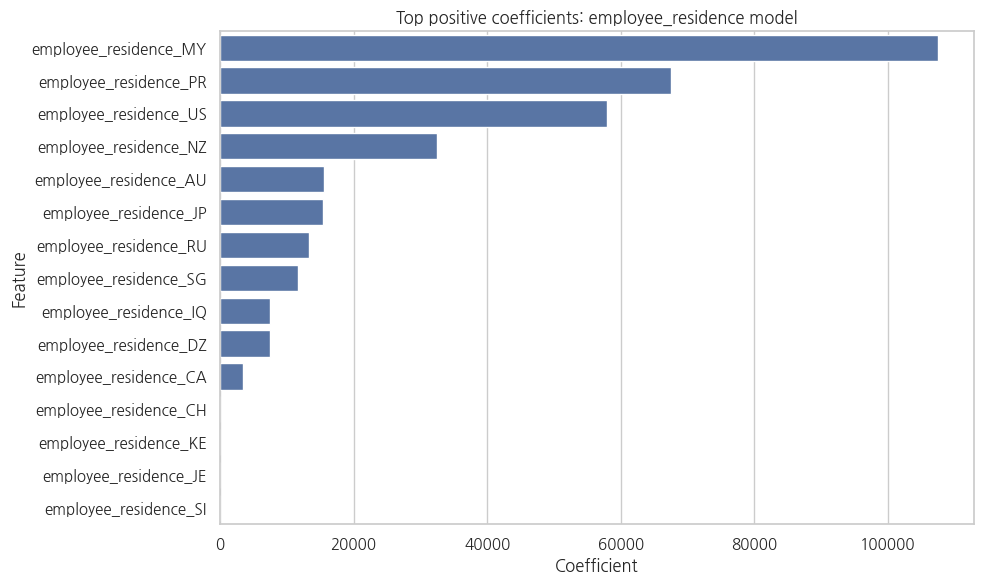

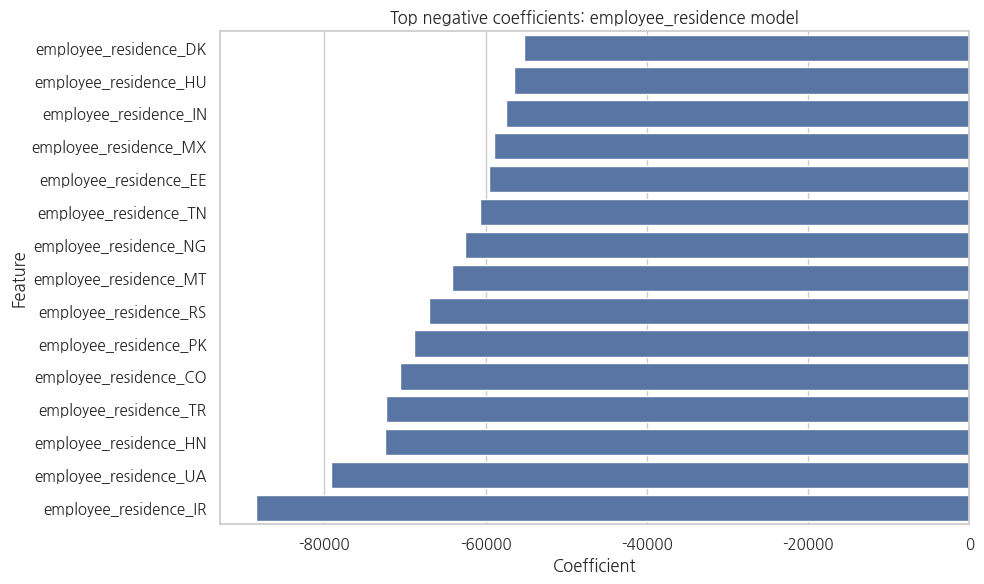

In [31]:
coef_residence = pd.DataFrame({
    'feature': X_a_encoded.columns,
    'coefficient': model_a.coef_
}).sort_values('coefficient', ascending=False)

display(coef_residence.head(15))
display(coef_residence.tail(15))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=coef_residence.head(15),
    x='coefficient',
    y='feature'
)
plt.title('Top positive coefficients: employee_residence model')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=coef_residence.tail(15),
    x='coefficient',
    y='feature'
)
plt.title('Top negative coefficients: employee_residence model')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

,feature,coefficient
42,company_location_RU,6.500000e+04
47,company_location_US,5.236822e+04
37,company_location_NZ,3.250000e+04
28,company_location_JP,2.898000e+04
23,company_location_IL,2.655900e+04
2,company_location_AU,1.554267e+04
5,company_location_CA,8.585750e+03
13,company_location_DZ,7.500000e+03
25,company_location_IQ,7.500000e+03
7,company_location_CL,5.093170e-11


,feature,coefficient
12,company_location_DK,-55247.500000
27,company_location_IT,-56133.500000
21,company_location_HU,-56765.000000
14,company_location_EE,-59526.000000
35,company_location_NG,-62500.000000
24,company_location_IN,-63469.333333
32,company_location_MT,-64131.000000
9,company_location_CO,-70656.000000
45,company_location_TR,-72329.000000
19,company_location_HN,-72500.000000


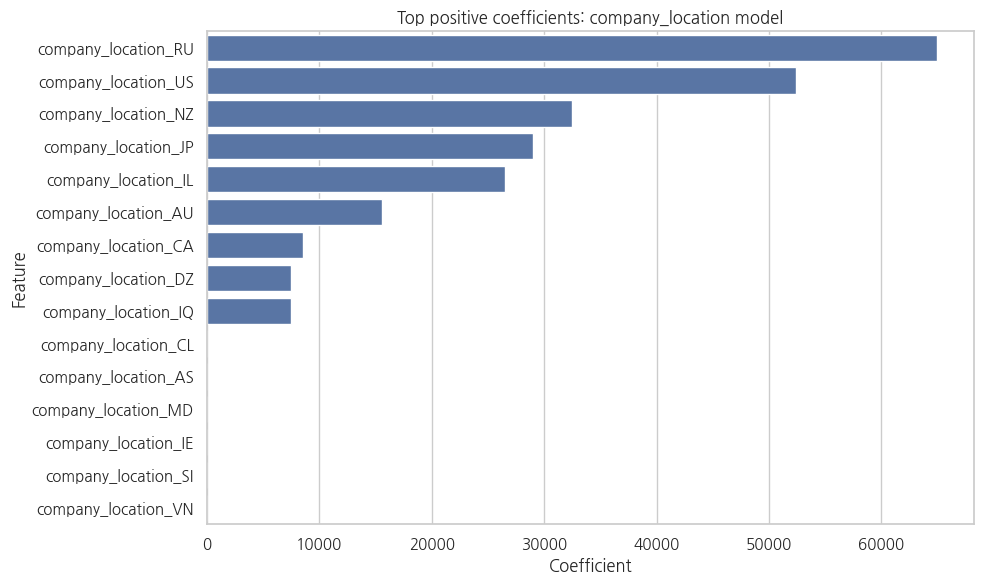

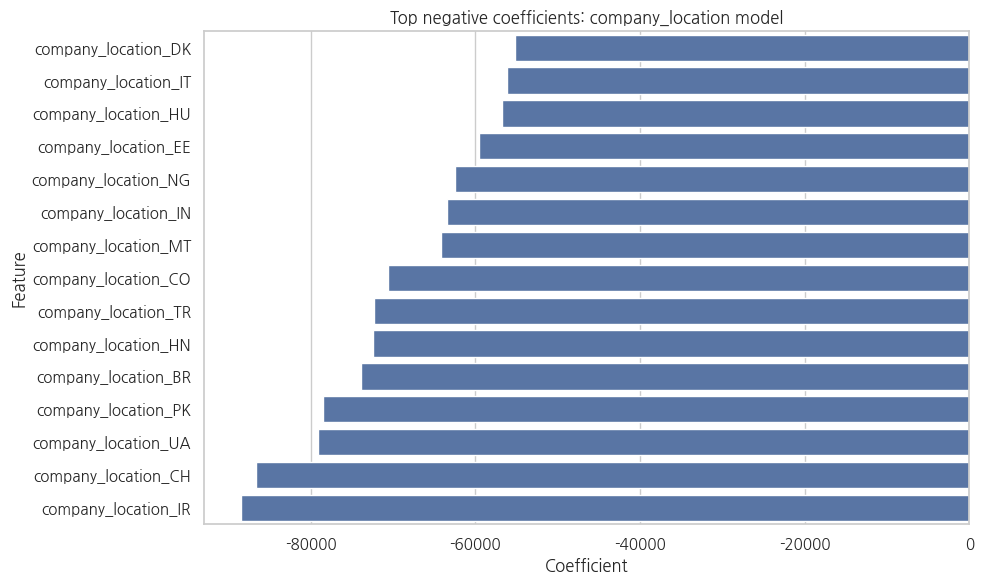

In [32]:
coef_company = pd.DataFrame({
    'feature': X_b_encoded.columns,
    'coefficient': model_b.coef_
}).sort_values('coefficient', ascending=False)

display(coef_company.head(15))
display(coef_company.tail(15))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=coef_company.head(15),
    x='coefficient',
    y='feature'
)
plt.title('Top positive coefficients: company_location model')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=coef_company.tail(15),
    x='coefficient',
    y='feature'
)
plt.title('Top negative coefficients: company_location model')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 16. 국가별 표본 수 확인

회귀계수는 반드시 표본 수와 함께 봐야 합니다.  
일부 국가는 데이터가 1~2개뿐일 수 있기 때문에, 계수가 크게 나와도 일반화하기 어렵습니다.

,employee_residence,count
0,US,332
1,GB,44
2,IN,30
3,CA,29
4,DE,25
5,FR,18
6,ES,15
7,GR,13
8,JP,7
9,PT,6


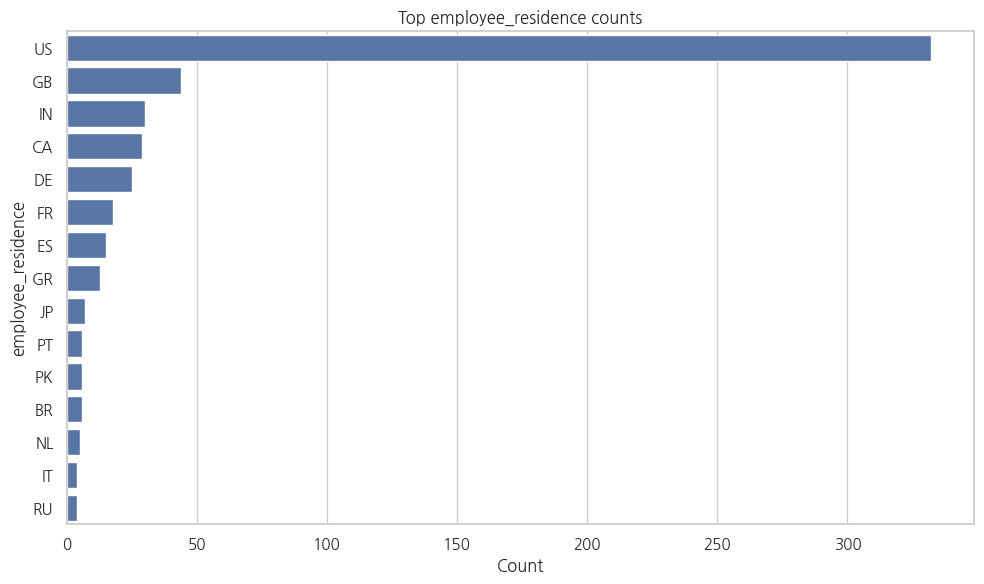

In [33]:
residence_count = df['employee_residence'].value_counts().reset_index()
residence_count.columns = ['employee_residence', 'count']

display(residence_count.head(20))

plt.figure(figsize=(10, 6))
sns.barplot(data=residence_count.head(15), y='employee_residence', x='count')
plt.title('Top employee_residence counts')
plt.xlabel('Count')
plt.ylabel('employee_residence')
plt.tight_layout()
plt.show()

,company_location,count
0,US,355
1,GB,47
2,CA,30
3,DE,28
4,IN,24
5,FR,15
6,ES,14
7,GR,11
8,JP,6
9,NL,4


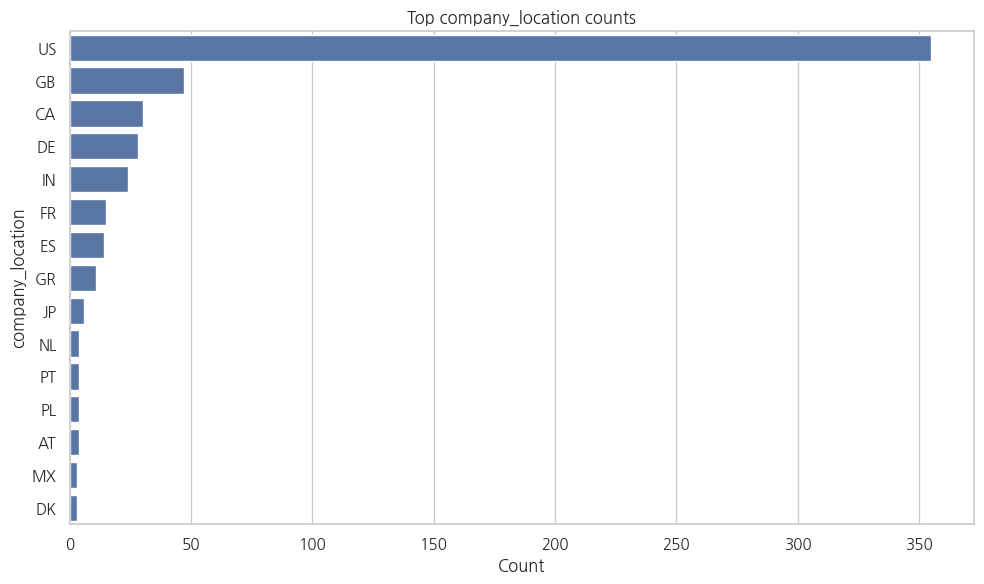

In [34]:
company_count = df['company_location'].value_counts().reset_index()
company_count.columns = ['company_location', 'count']

display(company_count.head(20))

plt.figure(figsize=(10, 6))
sns.barplot(data=company_count.head(15), y='company_location', x='count')
plt.title('Top company_location counts')
plt.xlabel('Count')
plt.ylabel('company_location')
plt.tight_layout()
plt.show()

## 17. [추가] 파생변수 기반 상관관계 히트맵

전체 국가 더미변수로 히트맵을 만들면 컬럼이 너무 많아져 해석이 어렵습니다.  
따라서 파생변수를 0/1 숫자형으로 변환해 간단한 상관관계 히트맵을 확인합니다.

,work_year,remote_ratio,is_us_residence_num,is_us_company_num,is_full_remote_num,same_country_num,salary_in_usd
work_year,1.000000,0.076314,0.289286,0.252017,0.185243,0.143137,0.170493
remote_ratio,0.076314,1.000000,0.171165,0.199119,0.928176,-0.092409,0.132122
is_us_residence_num,0.289286,0.171165,1.000000,0.912307,0.271178,0.308915,0.571803
is_us_company_num,0.252017,0.199119,0.912307,1.000000,0.298597,0.058174,0.531643
is_full_remote_num,0.185243,0.928176,0.271178,0.298597,1.000000,-0.073564,0.186057
same_country_num,0.143137,-0.092409,0.308915,0.058174,-0.073564,1.000000,0.151817
salary_in_usd,0.170493,0.132122,0.571803,0.531643,0.186057,0.151817,1.000000


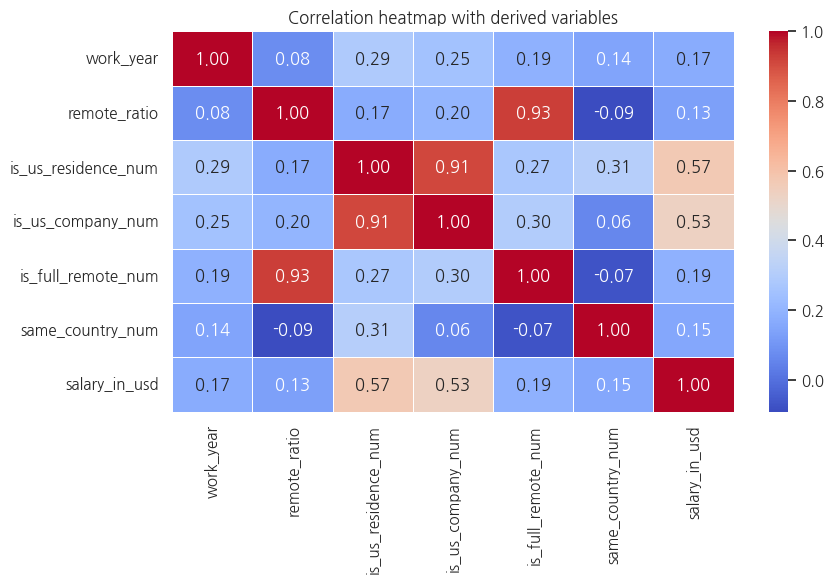

In [35]:
df['is_us_residence_num'] = np.where(df['employee_residence'] == 'US', 1, 0)
df['is_us_company_num'] = np.where(df['company_location'] == 'US', 1, 0)
df['is_full_remote_num'] = np.where(df['remote_ratio'] == 100, 1, 0)
df['same_country_num'] = np.where(df['employee_residence'] == df['company_location'], 1, 0)

corr_cols = [
    'work_year',
    'remote_ratio',
    'is_us_residence_num',
    'is_us_company_num',
    'is_full_remote_num',
    'same_country_num',
    'salary_in_usd'
]

corr_matrix = df[corr_cols].corr()

display(corr_matrix)

plt.figure(figsize=(9, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title('Correlation heatmap with derived variables')
plt.tight_layout()
plt.show()

## 18. [추가] K-Fold 교차검증

지금까지의 모델 평가는 데이터를 한 번만 train/test로 나눈 결과입니다.  
데이터가 607개로 크지 않기 때문에, 한 번의 분할 결과가 우연히 좋거나 나쁠 수 있습니다.

K-Fold 교차검증은 데이터를 여러 번 나누어 평균 성능을 확인하는 방법입니다.  
따라서 모델 결과의 안정성을 확인할 수 있습니다.

In [36]:
# K-Fold 교차검증용 평가 함수

def run_cv_model(X, y, model, model_name, n_splits=5):
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    scoring = {
        'MAE': 'neg_mean_absolute_error',
        'RMSE': 'neg_root_mean_squared_error',
        'R2': 'r2'
    }

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    result = {
        'model': model_name,
        'MAE_mean': -scores['test_MAE'].mean(),
        'MAE_std': scores['test_MAE'].std(),
        'RMSE_mean': -scores['test_RMSE'].mean(),
        'RMSE_std': scores['test_RMSE'].std(),
        'R2_mean': scores['test_R2'].mean(),
        'R2_std': scores['test_R2'].std()
    }

    return result

In [37]:
cv_results = []

cv_results.append(
    run_cv_model(
        X_a_encoded, y,
        LinearRegression(),
        'CV Linear: employee_residence only'
    )
)

cv_results.append(
    run_cv_model(
        X_b_encoded, y,
        LinearRegression(),
        'CV Linear: company_location only'
    )
)

cv_results.append(
    run_cv_model(
        X_c_encoded, y,
        LinearRegression(),
        'CV Linear: employee_residence + company_location'
    )
)

cv_location_results = pd.DataFrame(cv_results).sort_values('RMSE_mean')

display(cv_location_results)

,model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,CV Linear: employee_residence only,40011.421177,3804.958352,57829.290239,6753.239807,0.331065,0.072914
2,CV Linear: employee_residence + company_location,40564.510904,3033.767970,59157.152562,5385.565741,0.298734,0.044267
1,CV Linear: company_location only,40976.069257,3436.970868,59538.116483,5600.948068,0.289918,0.048606


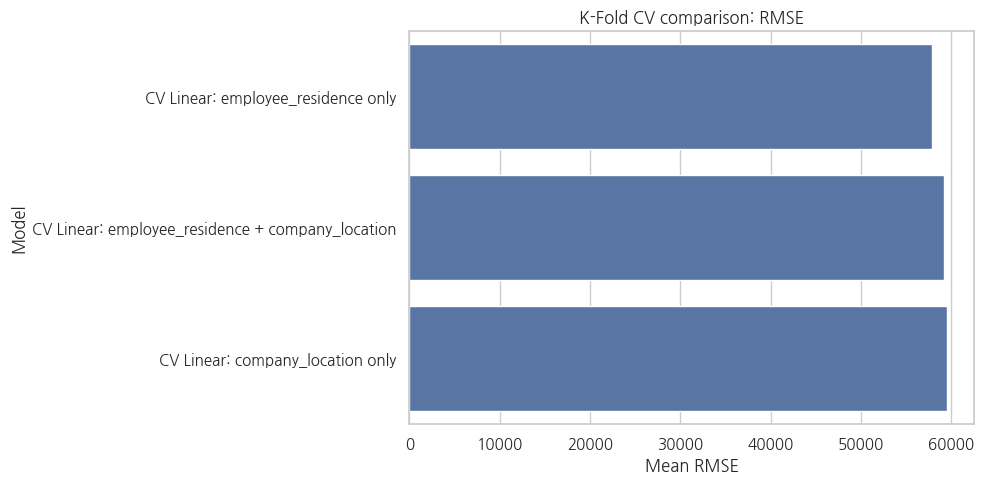

In [38]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=cv_location_results,
    y='model',
    x='RMSE_mean'
)
plt.title('K-Fold CV comparison: RMSE')
plt.xlabel('Mean RMSE')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

### K-Fold 해석

K-Fold 결과에서도 `employee_residence only` 모델이 RMSE_mean=57,829로 가장 낮고 R²_mean=0.33으로 가장 높습니다.  
이는 1회 train/test 분할 결과가 우연이 아님을 의미합니다.  
가설 B는 교차검증에서도 지지되지 않았습니다.

## 19. [추가] 로그 변환 모델링

연봉 데이터는 고연봉 이상치 때문에 오른쪽으로 긴 분포를 보입니다.  
이런 경우 `salary_in_usd`에 로그 변환을 적용하면 고연봉 이상치의 영향을 줄일 수 있습니다.

주의:
- 로그 변환 모델의 평가는 `log_salary` 기준이므로, 달러 단위 MAE/RMSE와 직접 비교하면 안 됩니다.
- R²로만 비교해야 합니다.

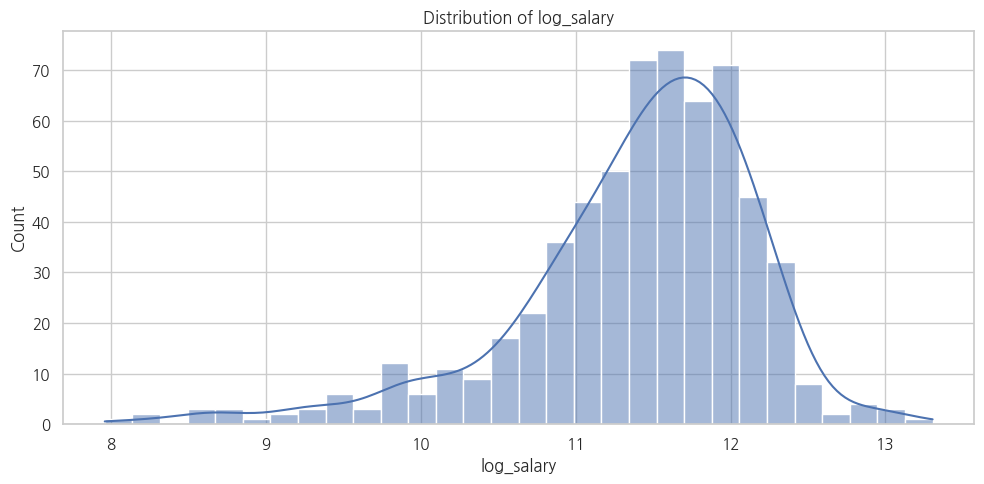

In [39]:
df['log_salary'] = np.log1p(df['salary_in_usd'])

plt.figure(figsize=(10, 5))
sns.histplot(df['log_salary'], bins=30, kde=True)
plt.title('Distribution of log_salary')
plt.xlabel('log_salary')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [40]:
y_log = df['log_salary']

# employee_residence only
X_train_a_log, X_test_a_log, y_train_a_log, y_test_a_log = train_test_split(
    X_a_encoded, y_log, test_size=0.2, random_state=42
)
log_model_a = LinearRegression()
log_model_a.fit(X_train_a_log, y_train_a_log)
log_pred_a = log_model_a.predict(X_test_a_log)
log_r2_a = r2_score(y_test_a_log, log_pred_a)

# company_location only
X_train_b_log, X_test_b_log, y_train_b_log, y_test_b_log = train_test_split(
    X_b_encoded, y_log, test_size=0.2, random_state=42
)
log_model_b = LinearRegression()
log_model_b.fit(X_train_b_log, y_train_b_log)
log_pred_b = log_model_b.predict(X_test_b_log)
log_r2_b = r2_score(y_test_b_log, log_pred_b)

# both
X_train_c_log, X_test_c_log, y_train_c_log, y_test_c_log = train_test_split(
    X_c_encoded, y_log, test_size=0.2, random_state=42
)
log_model_c = LinearRegression()
log_model_c.fit(X_train_c_log, y_train_c_log)
log_pred_c = log_model_c.predict(X_test_c_log)
log_r2_c = r2_score(y_test_c_log, log_pred_c)

log_model_results = pd.DataFrame({
    'model': [
        'log target: employee_residence only',
        'log target: company_location only',
        'log target: employee_residence + company_location'
    ],
    'R2_log': [log_r2_a, log_r2_b, log_r2_c]
})

display(log_model_results.sort_values('R2_log', ascending=False))

,model,R2_log
0,log target: employee_residence only,0.475079
2,log target: employee_residence + company_location,0.360549
1,log target: company_location only,0.268468


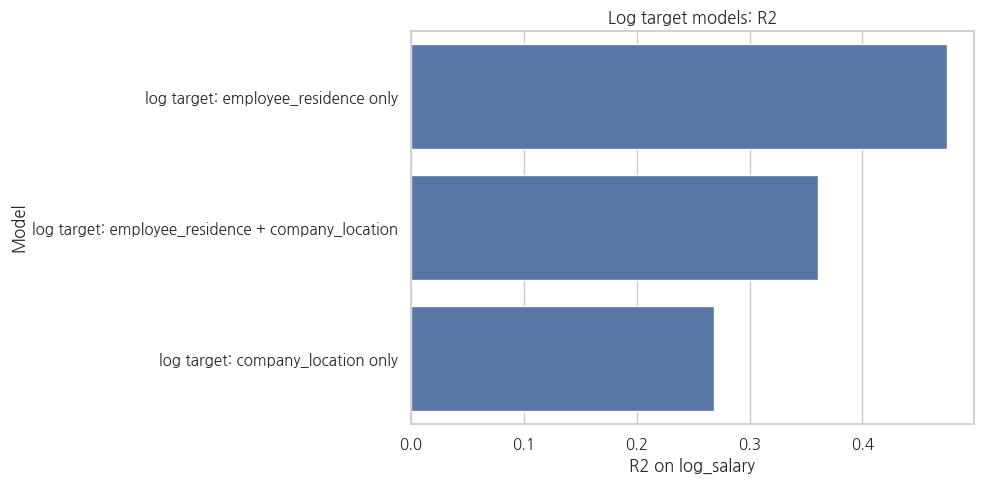

In [41]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=log_model_results.sort_values('R2_log', ascending=False),
    y='model',
    x='R2_log'
)
plt.title('Log target models: R2')
plt.xlabel('R2 on log_salary')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

### 로그 변환 해석

로그 변환 후 `employee_residence only` 모델의 R²는 0.475로, `company_location only`(0.269)보다 현저히 높습니다.  
오히려 이상치 영향을 줄인 뒤 두 모델의 성능 차이가 **더 뚜렷하게** 나타납니다.

이는 이전 결과(원본 스케일)가 고연봉 이상치의 영향이 아니었음을 보여줍니다.  
어떤 스케일에서도 직원 거주 국가가 더 유용한 변수라는 결론이 유지됩니다.

## 20. [추가] 전체 변수 모델링

지금까지는 가설만 보기 위해 위치 변수만 사용했습니다.  
하지만 실제 연봉은 경력 수준, 회사 규모, 원격근무 비율, 직무 등 여러 변수의 영향을 받습니다.

따라서 팀 전체 관점에서는 모든 주요 변수를 함께 넣은 전체 모델링이 필요합니다.

### 전체 모델링에 사용할 변수

| 변수 | 관련 가설 |
|---|---|
| `experience_level` | A: 직급이 연봉에 더 큰 영향을 끼친다 |
| `company_size` | A: 회사 규모 영향 |
| `employee_residence` | B: 직원 거주 국가 |
| `company_location` | B: 회사 위치 |
| `remote_ratio` | C: 원격 비중 |
| `work_year` | 연도별 시장 변화 보정 |
| `employment_type` | 고용 형태 보정 |
| `job_title` | 직무 차이 보정 |

In [42]:
full_features = [
    'work_year',
    'experience_level',
    'employment_type',
    'job_title',
    'employee_residence',
    'remote_ratio',
    'company_location',
    'company_size'
]

X_full = df[full_features]
y = df['salary_in_usd']

X_full_encoded = pd.get_dummies(X_full, drop_first=True)

print("원본 변수 수:", len(full_features))
print("원-핫 인코딩 후 변수 수:", X_full_encoded.shape[1])

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full_encoded, y, test_size=0.2, random_state=42
)

원본 변수 수: 8
원-핫 인코딩 후 변수 수: 164


In [43]:
# 전체 변수 Linear Regression
linear_full = LinearRegression()
linear_full.fit(X_train_full, y_train_full)
pred_linear_full = linear_full.predict(X_test_full)
linear_full_mae = mean_absolute_error(y_test_full, pred_linear_full)
linear_full_rmse = np.sqrt(mean_squared_error(y_test_full, pred_linear_full))
linear_full_r2 = r2_score(y_test_full, pred_linear_full)

# 전체 변수 Ridge Regression
ridge_full = Ridge(alpha=1.0)
ridge_full.fit(X_train_full, y_train_full)
pred_ridge_full = ridge_full.predict(X_test_full)
ridge_full_mae = mean_absolute_error(y_test_full, pred_ridge_full)
ridge_full_rmse = np.sqrt(mean_squared_error(y_test_full, pred_ridge_full))
ridge_full_r2 = r2_score(y_test_full, pred_ridge_full)

# 전체 변수 Random Forest Regressor
rf_full = RandomForestRegressor(n_estimators=300, random_state=42, max_depth=None)
rf_full.fit(X_train_full, y_train_full)
pred_rf_full = rf_full.predict(X_test_full)
rf_full_mae = mean_absolute_error(y_test_full, pred_rf_full)
rf_full_rmse = np.sqrt(mean_squared_error(y_test_full, pred_rf_full))
rf_full_r2 = r2_score(y_test_full, pred_rf_full)

full_model_results = pd.DataFrame({
    'model': [
        'Full Linear Regression',
        'Full Ridge Regression',
        'Full Random Forest Regressor'
    ],
    'MAE': [linear_full_mae, ridge_full_mae, rf_full_mae],
    'RMSE': [linear_full_rmse, ridge_full_rmse, rf_full_rmse],
    'R2': [linear_full_r2, ridge_full_r2, rf_full_r2]
})

display(full_model_results.sort_values('RMSE'))

,model,MAE,RMSE,R2
1,Full Ridge Regression,28099.617003,42260.021083,0.534018
2,Full Random Forest Regressor,27486.059572,42798.949170,0.522057
0,Full Linear Regression,36947.777745,58855.469300,0.096176


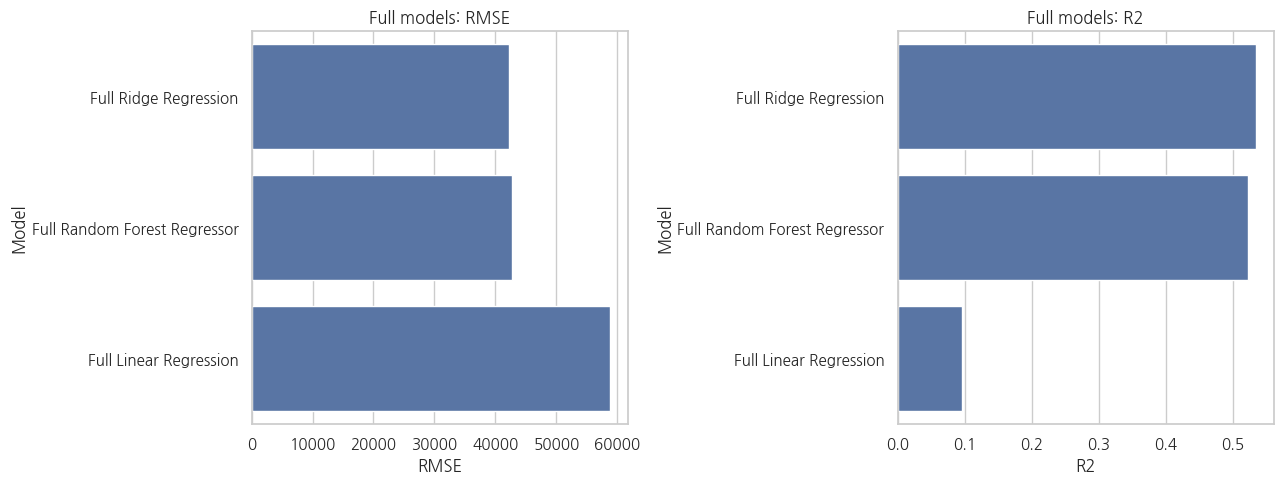

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_data = full_model_results.sort_values('RMSE')

sns.barplot(data=plot_data, y='model', x='RMSE', ax=axes[0])
axes[0].set_title('Full models: RMSE')
axes[0].set_xlabel('RMSE')
axes[0].set_ylabel('Model')

sns.barplot(data=plot_data.sort_values('R2', ascending=False), y='model', x='R2', ax=axes[1])
axes[1].set_title('Full models: R2')
axes[1].set_xlabel('R2')
axes[1].set_ylabel('Model')

plt.tight_layout()
plt.show()

### 전체 모델링 해석

Full Linear Regression R²=0.10, Full Ridge R²=0.53으로 큰 차이가 나는 이유:

원-핫 인코딩 후 변수가 매우 많아지면 OLS(일반 선형회귀)는 과적합에 취약해집니다.  
Ridge는 계수의 크기를 제한하는 규제(L2 regularization)를 추가해 이 문제를 완화합니다.  
따라서 변수 수가 많은 전체 모델에서는 Ridge와 Random Forest가 더 신뢰할 수 있는 결과를 제공합니다.

## 21. [추가] Ridge 계수 기반 전체 변수 해석

Ridge는 Linear Regression과 비슷하지만, 계수가 너무 커지는 것을 완화합니다.  
원-핫 인코딩으로 변수 수가 많아진 상황에서 계수를 조금 더 안정적으로 볼 수 있습니다.

,feature,coefficient,abs_coefficient
21,job_title_Data Analytics Lead,115536.997140,115536.997140
2,experience_level_EX,109199.278484,109199.278484
52,job_title_Principal Data Engineer,97888.696111,97888.696111
35,job_title_Financial Data Analyst,86987.029115,86987.029115
111,employee_residence_US,66563.554390,66563.554390
11,job_title_Applied Machine Learning Scientist,66043.743142,66043.743142
50,job_title_NLP Engineer,-58812.837741,58812.837741
53,job_title_Principal Data Scientist,55682.895834,55682.895834
112,employee_residence_VN,-55472.958319,55472.958319
19,job_title_Data Analyst,-50288.375399,50288.375399


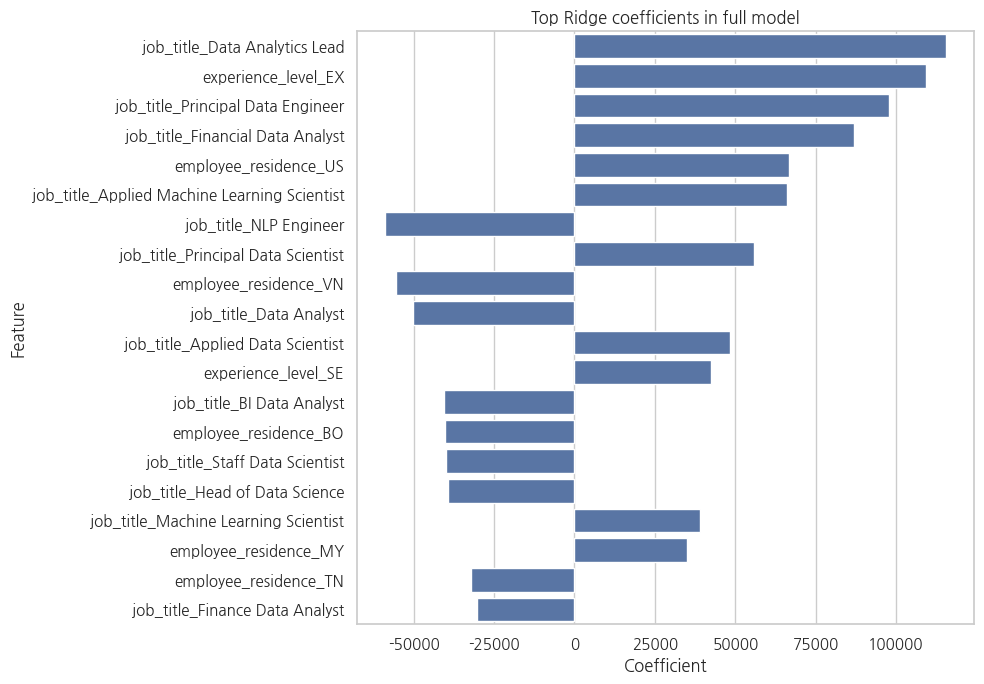

In [45]:
ridge_coef_full = pd.DataFrame({
    'feature': X_full_encoded.columns,
    'coefficient': ridge_full.coef_
})

ridge_coef_full['abs_coefficient'] = ridge_coef_full['coefficient'].abs()
ridge_coef_full = ridge_coef_full.sort_values('abs_coefficient', ascending=False)

display(ridge_coef_full.head(20))

plt.figure(figsize=(10, 7))
sns.barplot(
    data=ridge_coef_full.head(20),
    x='coefficient',
    y='feature'
)
plt.title('Top Ridge coefficients in full model')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## [추가] Random Forest Feature Importance

Random Forest는 여러 개의 결정트리를 결합한 모델입니다.  
Feature Importance를 통해 어떤 변수가 예측에 많이 사용되었는지 확인할 수 있습니다.

주의:
- Feature Importance는 모델 내부에서의 중요도이며 인과관계를 의미하지 않습니다.
- 원-핫 인코딩된 변수 단위로 중요도가 나오므로, 원래 변수 단위로 묶어서 보는 것이 더 좋습니다.

,feature,importance
111,employee_residence_US,0.347021
2,experience_level_EX,0.074207
52,job_title_Principal Data Engineer,0.046714
19,job_title_Data Analyst,0.045799
4,experience_level_SE,0.044167
11,job_title_Applied Machine Learning Scientist,0.032767
0,work_year,0.031300
55,job_title_Research Scientist,0.029831
35,job_title_Financial Data Analyst,0.028936
21,job_title_Data Analytics Lead,0.025975


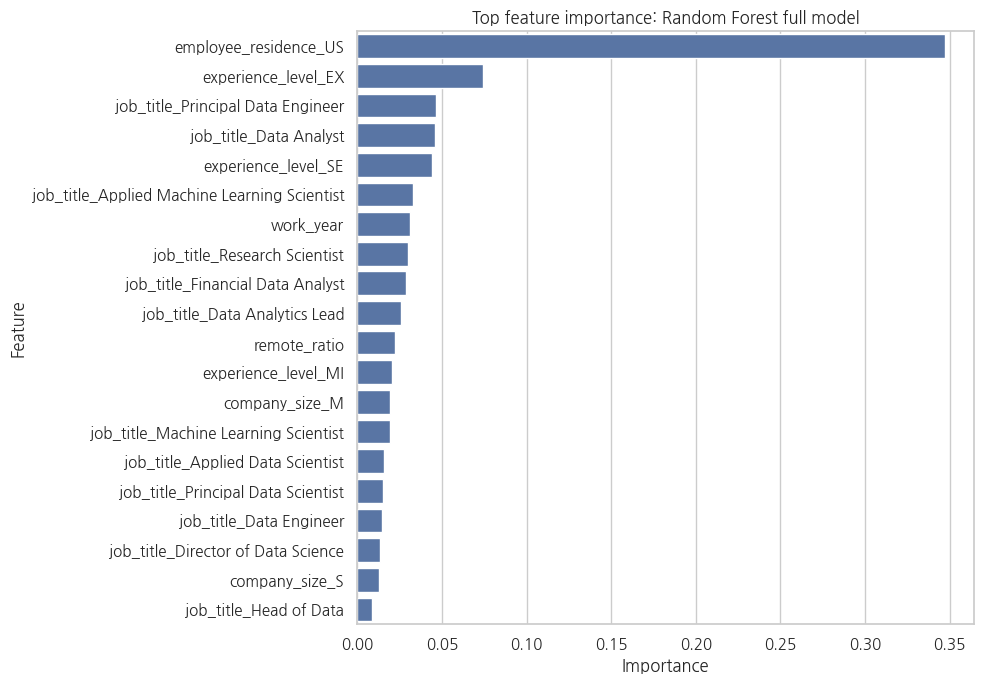

In [46]:
rf_importance = pd.DataFrame({
    'feature': X_full_encoded.columns,
    'importance': rf_full.feature_importances_
}).sort_values('importance', ascending=False)

display(rf_importance.head(30))

plt.figure(figsize=(10, 7))
sns.barplot(
    data=rf_importance.head(20),
    x='importance',
    y='feature'
)
plt.title('Top feature importance: Random Forest full model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 원래 변수 단위로 Feature Importance 묶기

원-핫 인코딩을 하면 `employee_residence_US`, `company_location_US`처럼 변수명이 많아집니다.  
팀 발표에서는 원래 변수 단위로 묶어 보는 것이 더 이해하기 쉽습니다.

,original_feature,importance
2,employee_residence,0.382253
5,job_title,0.357245
4,experience_level,0.138900
1,company_size,0.032160
7,work_year,0.031300
0,company_location,0.027733
6,remote_ratio,0.022462
3,employment_type,0.007947


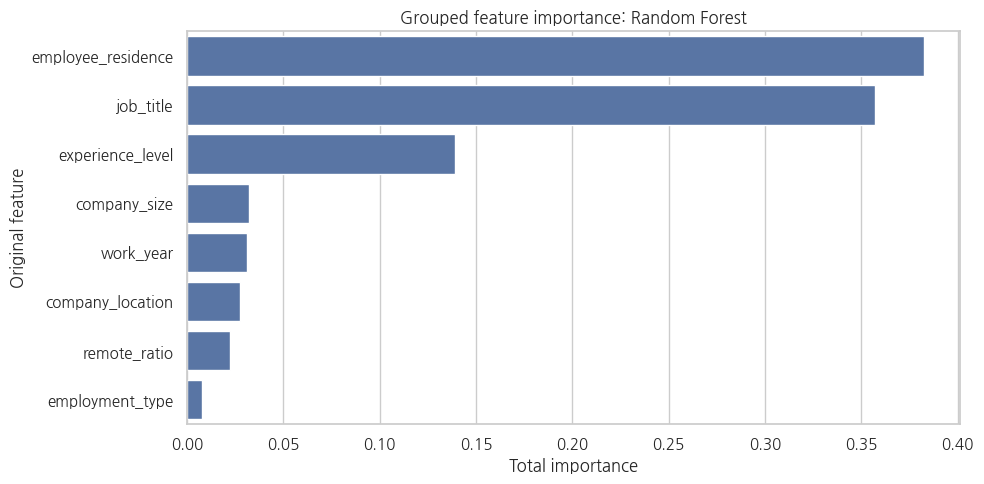

In [47]:
def map_original_feature(feature_name):
    if feature_name in ['work_year', 'remote_ratio']:
        return feature_name

    prefixes = [
        'experience_level',
        'employment_type',
        'job_title',
        'employee_residence',
        'company_location',
        'company_size'
    ]

    for prefix in prefixes:
        if feature_name.startswith(prefix + '_'):
            return prefix

    return feature_name

rf_importance['original_feature'] = rf_importance['feature'].apply(map_original_feature)

rf_group_importance = (
    rf_importance
    .groupby('original_feature')['importance']
    .sum()
    .reset_index()
    .sort_values('importance', ascending=False)
)

display(rf_group_importance)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=rf_group_importance,
    y='original_feature',
    x='importance'
)
plt.title('Grouped feature importance: Random Forest')
plt.xlabel('Total importance')
plt.ylabel('Original feature')
plt.tight_layout()
plt.show()

### 전체 Feature Importance 해석

| 중요도가 높게 나온 변수 | 연결되는 가설 | 중요도 |
|---|---|---|
| `employee_residence` | B 가설: 직원 거주 국가 영향 | 38.2% |
| `job_title` | 직무 차이 보정 | 35.7% |
| `experience_level` | A 가설: 직급이 연봉에 큰 영향을 주는가 | 13.9% |
| `company_size` | A 가설: 회사 규모 영향 | 3.2% |
| `company_location` | B 가설: 회사 위치 영향 | **2.8%** |
| `remote_ratio` | C 가설: 원격 비중 영향 | 2.2% |

**가설 관점**: `employee_residence`(38.2%) vs `company_location`(2.8%)  
다른 변수들을 모두 통제한 전체 모델에서도 두 변수의 영향력 차이가 유지됩니다.  
이는 위치 변수 간 독립 비교에서 나온 결론과 일치합니다.

## 최종 해석

### 가설
> 직원 거주 국가보다 회사 위치가 연봉에 더 큰 영향을 줄 것이다.

### EDA 결과
EDA에서는 회사 위치가 연봉에 영향을 줄 가능성이 일부 보였습니다.  
특히 미국 거주 + 미국 회사 조합은 높은 연봉 수준을 보였습니다.  
그러나 `US residence + Non-US company` 조합(n=2)은 통계적으로 무의미하며,  
대부분의 데이터(91.6%)에서 두 변수가 동일하여 독립적인 비교에 구조적 한계가 있습니다.

### 모델링 결과
1. **원본 변수 단순 비교**: `employee_residence only` RMSE=46,301, R²=0.44 > `company_location only` RMSE=49,585, R²=0.36
2. **K-Fold 교차검증**: `employee_residence only` RMSE_mean=57,829로 일관되게 더 좋음
3. **로그 변환 후**: `employee_residence` R²=0.475 vs `company_location` R²=0.269로 차이가 더 뚜렷해짐
4. **전체 변수 RF 중요도**: `employee_residence` 38.2% vs `company_location` 2.8%

### 최종 판단
**가설은 지지되지 않았습니다.**  
초기 예상과 달리, 이 데이터에서는 어떤 분석 방법을 사용해도 직원 거주 국가가 더 높은 설명력을 보였습니다.

### 한계점
- 두 변수가 91.6% 동일하여 독립적 비교의 구조적 한계 존재
- 미국 데이터 비중이 크고 일부 국가 조합의 표본이 매우 적음
- 위치 변수만으로는 연봉 전체를 설명하기 어려움 (최고 R²=0.44)
- 예측 성능 비교이지 인과관계 검증은 아님

### 개선 방향
- 거주지 ≠ 회사위치인 원격/해외 근무자(n=51)만 따로 분석하면 더 순수한 비교 가능
- 국가를 대륙/지역 단위로 그룹핑하면 표본 불균형 문제 완화 가능
- 전체 모델링에서 경력 수준, 직무, 회사 규모와 함께 위치 변수의 기여도를 재확인

## 요약 문장

> 가설은 '직원 거주 국가보다 회사 위치가 연봉에 더 큰 영향을 줄 것이다'로 설정했다.
>
> 분석 전 먼저 확인한 결과, 두 변수는 91.6%의 데이터에서 동일한 값을 가져 독립적인 비교에 구조적 한계가 있음을 확인했다.
>
> EDA에서는 미국 회사 소속 여부가 연봉에 영향을 줄 가능성이 일부 보였으나, 표본 수가 극히 적은 조합(n=2)이 포함되어 있어 단순 평균 비교만으로 결론을 내리기 어려웠다.
>
> 이후 머신러닝 모델링 결과, employee_residence 단독 모델이 RMSE 46,301, R² 0.44로 company_location 단독 모델(RMSE 49,585, R² 0.36)보다 일관되게 더 좋은 성능을 보였다.
>
> K-Fold 교차검증, 로그 변환 모델링, 전체 변수 Random Forest 중요도 분석에서도 동일한 결론이 유지되었다.
>
> 따라서 가설은 기각되었으며, 이 데이터에서는 어떤 방법을 사용해도 직원 거주 국가가 회사 위치보다 연봉 예측에 더 유용한 변수로 나타났다.